# Módulo 4: Construcción de características

## Tratamiento de categóricos IV: Frequency & Mean encoders

#### Objetivo 


* Conocer dos métodos nuevos para reemplazo de categorías así como el por qué éstos funcionarían bajo ciertas condiciones. 

#### Actividad 1

Tomar el dataset `actividad_11,0a` y conforme a los tipos de encoders realizar:
* Análisis de los funcionamientos y particularidades de cada uno de los métodos.

#### Actividad 2

Tomar la base de datos `actividad_11,0a.csv` de la plataforma y:
* Realizar dos modelos.
    * Cada uno de los modelos estarán encodeados con los métodos vistos en clase.

* Evalúa el performance del modelo mediante el cálculo de AUC. 
* Responde: 
    * ¿En qué casos no se podría usar el método de mean encoding? 
        * Pista: Recuerda que obtienes las medias solo con el set de entrenamiento. 
    * ¿Para qué sirven las gráficas de proporción variable vs proporción response? 
    * ¿Cuál de los dos métodos funcionó mejor? ¿Por qué? 
    


In [67]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.datasets import make_classification
from itertools import combinations
from matplotlib import pyplot as plt
from copy import deepcopy
import os

plt.style.use('ggplot')
%matplotlib inline
seed = 28
path = '.'

In [68]:
df = pd.read_csv('actividad_11,0a.csv')
df.head()

,Edad,Estado_residencia,Estado_nacimiento,Nombre_trabajo,Vacunado
0,55.138476,Sinaloa,Jalisco,Médico,0
1,37.035903,Jalisco,Jalisco,Médico,1
2,53.216657,Jalisco,Sinaloa,Chef,0
3,55.474971,Jalisco,Sinaloa,Policía,1
4,53.692812,Jalisco,Jalisco,Médico,1


### Frequency encoder

Hasta el momento hemos analizado distintos métodos de encoding pero en ninguno en realidad hemos observado la cantidad de instancias que caen en las categorías dadas.

Si bien este método no considera de ninguna manera la relación directa con la variable de respuesta, se espera que en un _set_ que hay muchas repeticiones de una misma categoría, ésta pueda tener relación con la variable de respuesta. 

El procedimiento para este _encoder_ es bastante sencillo: 

$$
F_i = \frac{\text{Apariciones de la variable } i }{\text{Total de instancias}}
$$

#### Encontrando la utilidad de este encoder

Hay que tener en cuenta que este _encoder_ solo se basa en la **proporción**, por lo que algo que podemos hacer para ver si este _encoder_ tiene sentido es hacer una comparación de justo estos elementos: 

* Proporción de response.
* Proporción de la categoría. 

In [69]:
# Agrupando
agrupacion = df.groupby('Estado_residencia').agg({'Vacunado': ['mean', 'std', 'count']})
agrupacion

Vacunado                 
                       mean       std  count
Estado_residencia                           
CDMX               0.152174  0.363158     46
Jalisco            0.644633  0.478643  13116
Sinaloa            0.224335  0.417174   6838

In [70]:
# Separando "columnas dobles"
agrupacion = agrupacion['Vacunado']
agrupacion

,mean,std,count
Estado_residencia,,,
CDMX,0.152174,0.363158,46
Jalisco,0.644633,0.478643,13116
Sinaloa,0.224335,0.417174,6838


In [71]:
# Obteniendo proporcion por categoreía
agrupacion['prop'] = agrupacion['count'] / agrupacion['count'].sum()
agrupacion

C:\Users\hecto\AppData\Local\Temp\ipykernel_6336\3664775209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agrupacion['prop'] = agrupacion['count'] / agrupacion['count'].sum()


,mean,std,count,prop
Estado_residencia,,,,
CDMX,0.152174,0.363158,46,0.0023
Jalisco,0.644633,0.478643,13116,0.6558
Sinaloa,0.224335,0.417174,6838,0.3419


In [72]:
# Ordenemos el DataFrame por proprociones.
agrupacion = agrupacion.sort_values('prop')
agrupacion

,mean,std,count,prop
Estado_residencia,,,,
CDMX,0.152174,0.363158,46,0.0023
Sinaloa,0.224335,0.417174,6838,0.3419
Jalisco,0.644633,0.478643,13116,0.6558


[Text(0.0023, 0, 'CDMX: 0.002'),
 Text(0.3419, 0, 'Sinaloa: 0.342'),
 Text(0.6558, 0, 'Jalisco: 0.656')]

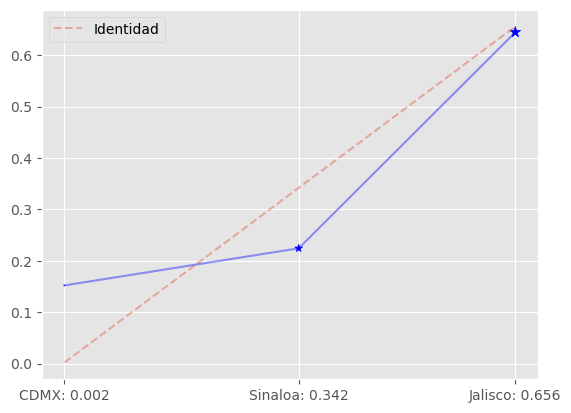

In [73]:
# Graficando
fig, ax = plt.subplots()


# Graficando los puntos
x = agrupacion['prop']
y = agrupacion['mean']

# Graficando la línea
ax.scatter(x, y, s=x*100, color='blue', marker='*')
ax.plot(x, y, color='blue', alpha=0.4)

# Línea identidad
min_ = agrupacion[['mean', 'prop']].min().min()
max_ = agrupacion[['mean', 'prop']].max().max()

ax.plot([min_, max_], [min_, max_], linestyle='--', alpha=0.4, label='Identidad')

# Leyenda
ax.legend()

# Etiquetas
ax.set_xticks(x)
xticklabels = [f'{i}: {agrupacion.loc[i, "prop"].round(3)}' for i in agrupacion.index]

# Xticks
ax.set_xticklabels(xticklabels)

En el caso de "Estado de residencia", vemos que a mayor concentración de la categoría, mayor concentración de la variable de respuesta también. 

Observaciones importantes:

* No necesitamos estar en la línea identidad (línea roja). Ésta sola nos da una idea de si la concentración del response es similar a la proporción que hay de la misma en el set. 
    * Arriba de la línea roja quiere decir que hay mayor concentración de 1s que de la categoría en el set. 
* Si una variable con baja proporción (caso de la CDMX) tiene muchos 1s puede que sea buena, pero si ésta (la proporción) es baja, tendrá poca representatividad. 
* Buscamos una variable que tenga diferentes concentraciones, algunas categorías con muchos 1s y otras con muchos 0s. 




#### Generalicemos


In [74]:
# Separando categorías
cats = df.select_dtypes(include = ['object']).columns

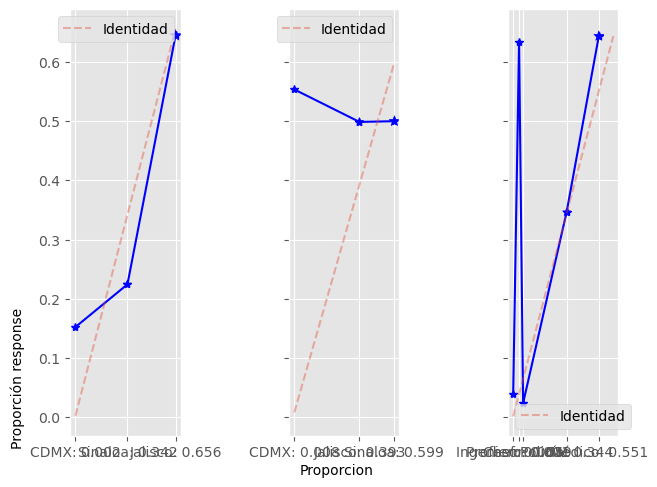

In [75]:
# Plotting
fig, axes = plt.subplots(nrows=1, ncols=len(cats), sharey=True)
    
for index, col in enumerate(cats):
    ax = axes[index]
    # Agrupacion
    agrupacion = df.groupby(col).agg({'Vacunado': ['mean', 'std', 'count']})['Vacunado']
    
    # Obtener proporciones
    agrupacion['prop'] = agrupacion['count'] / agrupacion['count'].sum()
    
    # Ordenar
    agrupacion = agrupacion.sort_values('prop')
    
    # Mínimos y máximos para línea identidad
    min_ = agrupacion[['mean', 'prop']].min().min()
    max_ = agrupacion[['mean', 'prop']].max().max()

    # Plot
    x = agrupacion['prop']
    y = agrupacion['mean']

    # Graficando los puntos
    ax.scatter(x,y,s=x*100, color='blue',marker='*')
    

    # Graficando la línea
    ax.plot(x,y,color='blue',marker='*')

    # Línea identidad
    ax.plot([min_, max_], [min_, max_], linestyle='--', alpha=0.4, label='Identidad')

    # Leyenda
    ax.legend()

    # Etiquetas
    ax.set_xticks(x)
    xticklabels = [f'{i}: {agrupacion.loc[i, "prop"].round(3)}' for i in agrupacion.index]

    # Xticks
    ax.set_xticklabels(xticklabels)
    
# Ejes generales
fig.text(0.5,0.001, 'Proporcion', ha='center')
fig.text(0.001,0.06, 'Proporción response', ha='center', rotation='vertical')

fig.tight_layout()

#### Observaciones 
* Típicamente hay 2 categorías con la mayor concentración de población en todas las variables. 
* Salvo `estado_nacimiento` todas tienen cambios importantes entre sus categorías. 
* `Estado_nacimiento` no tiene variación entre sus categorías, quizá no sirva para discriminar. 
    * Ojo: Esto NO es concluyente, puede que funcione en combinación con otras, estamos viendo únicamente **contribuciones individuales.**
    
    


#### Aplicando el método

In [76]:
# Separando sets
predictores = [c for c in df if c != 'Vacunado']
train_x, test_x, train_y, test_y = train_test_split(
    df[predictores],
    df['Vacunado'],
    test_size=0.2,
    random_state=seed
)
    

In [77]:
# Creando proporciones
props = {}

for col in cats:
    # Contando elementos
    counts = train_x.groupby(col)[col].count()
    
    # Obteniendo proporciones
    props[col] = (counts/len(train_x)).to_dict()

props

{'Estado_residencia': {'CDMX': 0.0024375,
  'Jalisco': 0.656125,
  'Sinaloa': 0.3414375},
 'Estado_nacimiento': {'CDMX': 0.008125,
  'Jalisco': 0.390375,
  'Sinaloa': 0.6015},
 'Nombre_trabajo': {'Chef': 0.0643125,
  'Ingeniero': 0.0013125,
  'Médico': 0.549875,
  'Policía': 0.344625,
  'Profesor': 0.039875}}

In [ ]:
# Reemplazando
train_x.replace(props, inplace=True)

C:\Users\hecto\AppData\Local\Temp\ipykernel_6336\3715098484.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_x.replace(props, inplace=True)


En este punto vale la pena mencionar: 
* Las proporciones siempre estarán entre 0 y 1, por lo que podemos usar el método de máximos para estandarizar las variables numéricas. 
* Aun así podemos usar en este punto el método de `Z-scores` para estandarizar y las categorías seguirán siendo "individuales". 

In [81]:
train_x

,Edad,Estado_residencia,Estado_nacimiento,Nombre_trabajo
15064,59.657879,0.341438,0.601500,0.344625
15201,56.580054,0.341438,0.601500,0.344625
12837,37.361208,0.656125,0.601500,0.549875
4048,39.950896,0.656125,0.390375,0.344625
5221,51.934738,0.656125,0.601500,0.344625
...,...,...,...,...
16471,53.220532,0.656125,0.601500,0.344625
7427,37.845518,0.656125,0.601500,0.549875
7200,55.275351,0.656125,0.601500,0.549875
4089,47.170884,0.656125,0.390375,0.549875


## Mean encoder 

Después de haber visto `WoEs` este método es muy sencillo, su base es el promedio de la variable de respuesta a través de categorías de entrenamiento. 

In [79]:


# Generemos un set de entrenamiento que tenga la variable de respuest


Obtendremos esto mismo por cada columna y reemplazaremos. 

Reemplazamos